In [4]:
from astroquery.vizier import Vizier # getting vizier data from astroquery
import astropy.units as u
import numpy as np

GALAH_DR4_DATA = Vizier.find_catalogs("GALAH DR4") #finding the data
# reference code --> https://astroquery.readthedocs.io/en/latest/vizier/vizier.html
GALAH_DR4 = Vizier.get_catalogs(GALAH_DR4_DATA.keys()) #getting the catalog in python
print('\nData Keys =', GALAH_DR4_DATA.keys()) # finding the different catalogs within the GALAH data
print('') #making the output legible

DR4_catalog = Vizier.get_catalogs('J/A+A/703/A104')[0] #getting the specific data we want
print('\nJ/A+A catalog key =', DR4_catalog.keys())
print('')

dr4_table_columns = DR4_catalog['GALAH', '[Fe/H]', 'RAJ2000', 'DEJ2000', 'RVGaiaDR3'] #getting table that has star ID, velocities from Gaia, right ascension, declination and Fe/H
print(dr4_table_columns)



Data Keys = odict_keys(['II/385', 'V/153', 'J/ApJS/228/24', 'J/A+A/703/A104', 'J/MNRAS/478/4513', 'J/MNRAS/506/150'])


J/A+A catalog key = ['More', 'GALAH', 'RAJ2000', 'DEJ2000', 'RV1', 'RV2', 'RVGaiaDR3', 'Teff', 'logg', '[Fe/H]', 'vmic', '[Li/Fe]', '[C/Fe]', '[O/Fe]', '[Na/Fe]', '[Mg/Fe]', '[Al/Fe]', '[Si/Fe]', '[K/Fe]', '[Ca/Fe]', '[Sc/Fe]', '[Ti/Fe]', '[V/Fe]', '[Cr/Fe]', '[Mn/Fe]', '[Co/Fe]', '[Ni/Fe]', '[Cu/Fe]', '[Zn/Fe]', '[Rb/Fe]', '[Sr/Fe]', '[Y/Fe]', '[Zr/Fe]', '[Mo/Fe]', '[Ru/Fe]', '[Ba/Fe]', '[La/Fe]', '[Ce/Fe]', '[Nd/Fe]', '[Sm/Fe]', '[Eu/Fe]']

     GALAH        [Fe/H]      RAJ2000         DEJ2000      RVGaiaDR3 
                                deg             deg          km / s  
--------------- --------- --------------- --------------- -----------
131216002101369 -0.476275 116.22066497803 -58.58015441895    3.206535
131216002101370  0.162921 116.35832214355 -58.55486297607   68.482262
131216002101371 -0.070264 115.57059478760 -58.76958084106    2.458487
131216002101

In [23]:
# need to make different tables for stars of low, intermediate and high metallicity
print('\nHigh metallicity stars') # using values above 0 to find high metallicity stars
positive_feh = dr4_table_columns[dr4_table_columns['[Fe/H]'] > 0.2]
print(positive_feh)
print('')

print('\nLow metallicity stars') # finding balues below 0 to find low metallicity stars
negative_feh = dr4_table_columns[dr4_table_columns['[Fe/H]'] < -0.2]
print(negative_feh)

print('\nIntermediate metallicity stars') # finding values between -0.25 and 0.25 to find intermediate metallicity stars
intermediate_feh = dr4_table_columns[(dr4_table_columns['[Fe/H]'] >= -0.2) & (dr4_table_columns['[Fe/H]'] <= 0.2)]
# currently needing to select make output scrollable to see all the data

print(intermediate_feh)


High metallicity stars
     GALAH        [Fe/H]      RAJ2000         DEJ2000      RVGaiaDR3 
                                deg             deg          km / s  
--------------- --------- --------------- --------------- -----------
131216002101393  0.219576 116.33971405029 -58.81902694702   36.897358
131216002601003  0.333839 148.19090270996  26.00695419312          --
131217001801011  0.206226   4.46583318710   0.37033334374   -5.218931
131217001801015  0.239651   4.14420843124   0.38177776337  -25.176628


Low metallicity stars
     GALAH        [Fe/H]      RAJ2000         DEJ2000      RVGaiaDR3 
                                deg             deg          km / s  
--------------- --------- --------------- --------------- -----------
131216002101369 -0.476275 116.22066497803 -58.58015441895    3.206535
131216002101373 -0.318378 116.57711029053 -58.53701400757  313.863556
131216002101375 -0.369453 116.19264984131 -58.64999771118   96.037407
131216002101380 -0.396730 115.92316436768 


Negative Metallicity Stars and their radial velocities
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\jrh28\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Text(0.5, 1.0, 'Radial Velocity Distribution of Stars with Negative Metallicity')

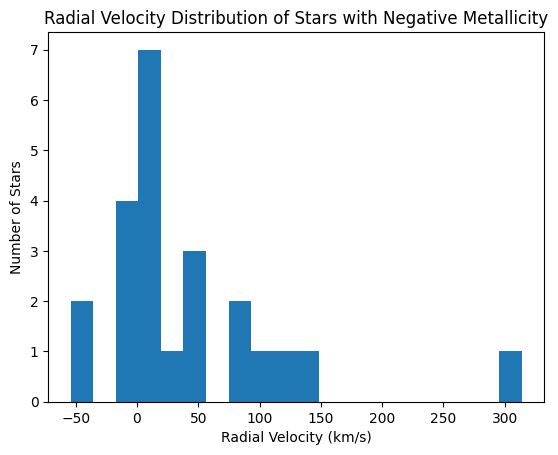

In [24]:

# FINDING RADIAL VELOCITIES OF LOW METALLICITY STARS
print('\nNegative Metallicity Stars and their radial velocities')
negfehrv = dr4_table_columns[dr4_table_columns['[Fe/H]'] < -0.2]['RVGaiaDR3']

%pip install matplotlib # getting matplot so I can plot data
import matplotlib.pyplot as plt
import numpy as np

plt.hist(negfehrv, bins=20)
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('Number of Stars')
plt.title('Radial Velocity Distribution of Stars with Negative Metallicity')

# Why does the data show stars with both positive and negative radial velocities?
# Radial velocity is relative to whether the star is moving towards or away from the observer.
# Therefore stars with positive radial velocities are moving away from us
# and stars with negative radial velocities are moving towards us.
# From this graph we can see potentially two populations of stars within the milky way
# that move in two seperate directions.
# Furthermore, there is potentially another group of stars with a very high radial velocity
# having a radial velocity of around 300km/s compared to the nearest value of almost 150km/s.

# Because of the high velocity, it is reasonable to be critical of the data points as they could
# potentially be stars that have reached escape velocity for the milkyway and have been ejected
# however, using the value of the escape velocity of the Milky Way being around 550km/s (Koppelman, 21).
# As the 300km/s is much lower than 550 km/s we can safely reject the possibility of the stars
# being ejected from the milky way and we can include them in our data set.


Intermediate Metallicity Stars and their radial velocities


Text(0.5, 1.0, 'Radial Velocity Distribution of Stars with Intermediate Metallicity')

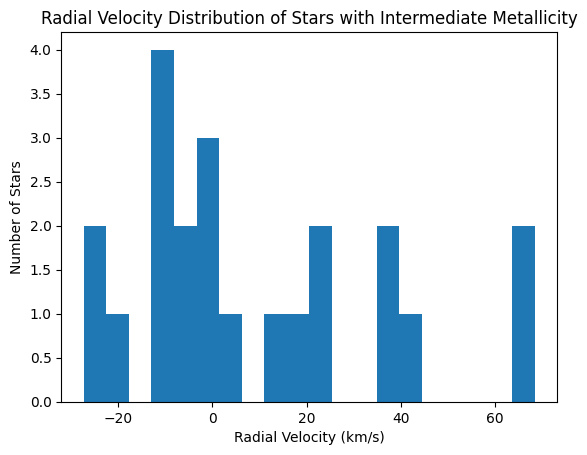

In [25]:
# FINDING RADIAL VELOCITY OF INTERMEDIATE METALLICITY STARS
print('\nIntermediate Metallicity Stars and their radial velocities')
intfehrv = dr4_table_columns[(dr4_table_columns['[Fe/H]'] >= -0.2) & (dr4_table_columns['[Fe/H]'] <= 0.2)]['RVGaiaDR3']

plt.hist(intfehrv, bins=20)
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('Number of Stars')
plt.title('Radial Velocity Distribution of Stars with Intermediate Metallicity')



High Metallicity Stars and their radial velocities


Text(0.5, 1.0, 'Radial Velocity Distribution of Stars with High Metallicity')

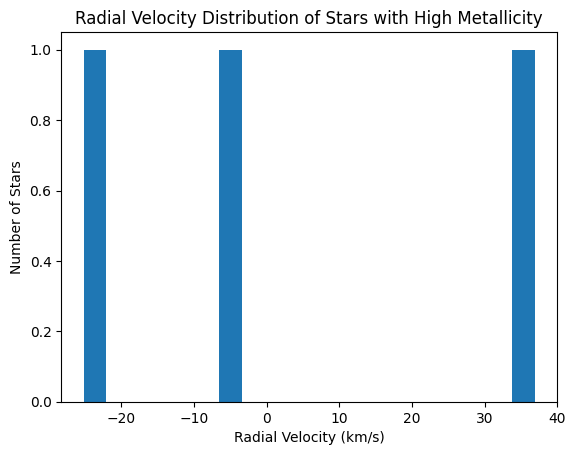

In [26]:
# FINDING RADIAL VELOCITY OF HIGH METALLICITY STARS
print('\nHigh Metallicity Stars and their radial velocities')
highfehrv = dr4_table_columns[dr4_table_columns['[Fe/H]'] > 0.2]['RVGaiaDR3']

plt.hist(highfehrv, bins=20)
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('Number of Stars')
plt.title('Radial Velocity Distribution of Stars with High Metallicity')
